## 1. Importing Libraries


In [1]:
# Install required packages (run once in Colab)
!pip install numpy==1.23.5 gensim nltk wordcloud gradio -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 43.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [2]:
# Standard
import re
import time
import warnings
warnings.filterwarnings('ignore')

# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# NLP – NLTK
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Deep learning
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# Pre-trained word embeddings
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'gensim', '-q'])
import gensim.downloader as gensim_api

print(f"TensorFlow: {tf.__version__} | NumPy: {np.__version__}")

TensorFlow: 2.20.0 | NumPy: 2.0.2


In [3]:
# Mount Google Drive if running in Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Data Loading


In [4]:
# Define file paths for the training and test datasets
TRAIN_DATA_PATH = '/content/drive/MyDrive/train_racisit.csv'
TEST_DATA_PATH  = '/content/drive/MyDrive/test_racisit.csv'

# Load training and test data into Pandas DataFrames using the defined paths
train_df = pd.read_csv(TRAIN_DATA_PATH)
test_df  = pd.read_csv(TEST_DATA_PATH)


In [5]:
# Display basic shape information and preview the first rows of the training set
print(f"Train shape: {train_df.shape} | Test shape: {test_df.shape}")
train_df.head()


Train shape: (31962, 3) | Test shape: (17197, 2)


,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


In [6]:
test_df.head()

,id,tweet
0,31963,#studiolife #aislife #requires #passion #dedic...
1,31964,@user #white #supremacists want everyone to s...
2,31965,safe ways to heal your #acne!! #altwaystohe...
3,31966,is the hp and the cursed child book up for res...
4,31967,"3rd #bihday to my amazing, hilarious #nephew..."


## 3. Data Understanding & Exploratory Analysis


In [7]:
# Inspect column data types and check for any missing values in the training set
train_df.info()
print("\nMissing values:\n", train_df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31962 entries, 0 to 31961
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      31962 non-null  int64 
 1   label   31962 non-null  int64 
 2   tweet   31962 non-null  object
dtypes: int64(2), object(1)
memory usage: 749.2+ KB

Missing values:
 id       0
label    0
tweet    0
dtype: int64


In [8]:
# Compute class distribution: count and percentage of each label in the training set
class_counts = train_df['label'].value_counts()
print(f"Class 0 (Non-Hate): {class_counts[0]} ({class_counts[0]/len(train_df)*100:.1f}%)")
print(f"Class 1 (Hate)    : {class_counts[1]} ({class_counts[1]/len(train_df)*100:.1f}%)")


Class 0 (Non-Hate): 29720 (93.0%)
Class 1 (Hate)    : 2242 (7.0%)


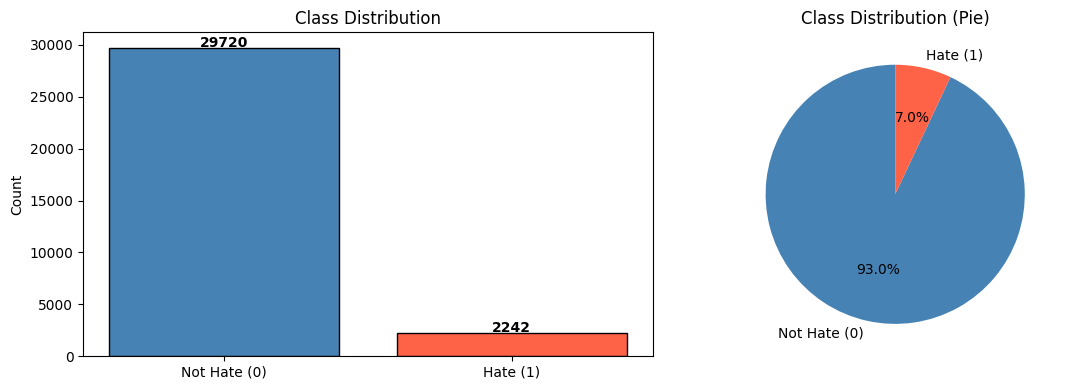

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(['Not Hate (0)', 'Hate (1)'], class_counts.values,
            color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

axes[1].pie(class_counts.values, labels=['Not Hate (0)', 'Hate (1)'],
            autopct='%1.1f%%', colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Class Distribution (Pie)')
plt.tight_layout()
plt.show()

In [10]:
# Compute word count per tweet to understand length distribution across classes
train_df['word_count'] = train_df['tweet'].apply(lambda x: len(str(x).split()))
print(train_df['word_count'].describe())


count    31962.00000
mean        13.15872
std          5.47815
min          3.00000
25%          9.00000
50%         13.00000
75%         17.00000
max         34.00000
Name: word_count, dtype: float64


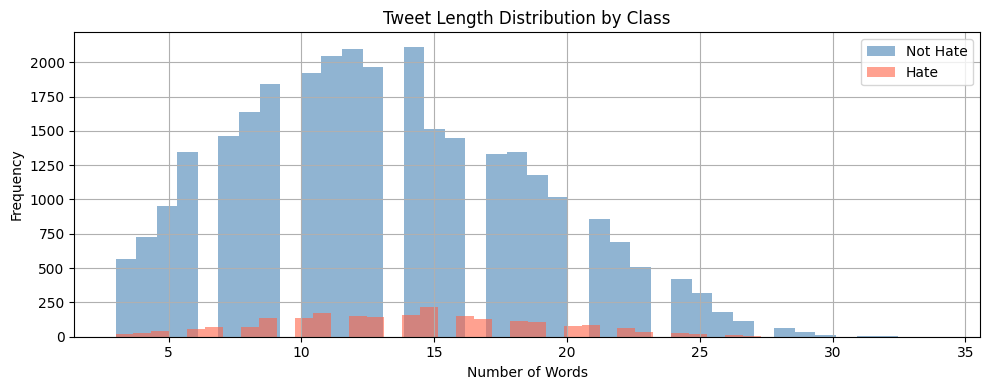

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
train_df[train_df['label'] == 0]['word_count'].hist(bins=40, alpha=0.6, color='steelblue', label='Not Hate', ax=ax)
train_df[train_df['label'] == 1]['word_count'].hist(bins=40, alpha=0.6, color='tomato', label='Hate', ax=ax)
ax.set_title('Tweet Length Distribution by Class')
ax.set_xlabel('Number of Words')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

In [12]:
# Display representative sample tweets from each class for qualitative inspection
print("Non-Hate tweet samples:")
for tweet_text in train_df[train_df['label'] == 0]['tweet'].head(3).values:
    print(" •", tweet_text)

print("\nHate tweet samples:")
for tweet_text in train_df[train_df['label'] == 1]['tweet'].head(3).values:
    print(" •", tweet_text)


Non-Hate tweet samples:
 •  @user when a father is dysfunctional and is so selfish he drags his kids into his dysfunction.   #run
 • @user @user thanks for #lyft credit i can't use cause they don't offer wheelchair vans in pdx.    #disapointed #getthanked
 •   bihday your majesty

Hate tweet samples:
 • @user #cnn calls #michigan middle school 'build the wall' chant '' #tcot  
 • no comment!  in #australia   #opkillingbay #seashepherd #helpcovedolphins #thecove  #helpcovedolphins
 • retweet if you agree! 


## 4. Text Preprocessing, Tokenization, and Sequence Padding

### 4.1 Preprocessing Configuration


In [13]:
# Contraction mapping used to normalise informal text (e.g. "don't" → "do not")
CONTRACTION_MAP = {
    "don't": "do not", "can't": "cannot", "won't": "will not",
    "isn't": "is not", "aren't": "are not", "wasn't": "was not",
    "weren't": "were not", "haven't": "have not", "hasn't": "has not",
    "hadn't": "had not", "didn't": "did not", "doesn't": "does not",
    "wouldn't": "would not", "couldn't": "could not", "shouldn't": "should not",
    "i'm": "i am", "i've": "i have", "i'll": "i will", "i'd": "i would",
    "it's": "it is", "that's": "that is", "what's": "what is",
    "he's": "he is", "she's": "she is", "they're": "they are",
    "you're": "you are", "we're": "we are", "you've": "you have",
    "they've": "they have", "you'll": "you will", "they'll": "they will",
    "let's": "let us", "there's": "there is",
}

# Load English stopwords and initialise the lemmatizer once for reuse across calls
ENGLISH_STOPWORDS = set(stopwords.words('english'))
text_lemmatizer   = WordNetLemmatizer()


### 4.2 Contraction Expansion


In [14]:
def expand_contractions(raw_text):
    """
    Expand English contractions in a string using a predefined mapping.

    Parameters
    raw_text : str
        Input text that may contain contractions (e.g. "don't").

    Returns
    str
        Text with all recognised contractions replaced by their full forms.
    """
    for contraction, full_form in CONTRACTION_MAP.items():
        raw_text = raw_text.replace(contraction, full_form)
    return raw_text


### 4.3 Cleaning Pipeline


In [15]:
def clean_tweet(raw_text):
    """
    Apply a full NLP preprocessing pipeline to a single tweet.

    Steps applied in order:
    1. Lowercase all characters to ensure uniformity.
    2. Remove URLs (http/https and www).
    3. Remove user mentions (@username).
    4. Strip hashtag symbols (#) while keeping the word.
    5. Expand contractions using CONTRACTION_MAP.
    6. Remove non-alphabetic characters (numbers, punctuation, special chars).
    7. Tokenize and remove English stopwords and very short tokens (<= 2 chars).
    8. Lemmatize each remaining token to reduce it to its base form.

    Parameters
    raw_text : str
        Original tweet text.

    Returns
    str
        Cleaned, preprocessed tweet as a single space-separated string.
    """
    # Step 1: Lowercase
    cleaned = str(raw_text).lower()
    # Step 2: Remove URLs
    cleaned = re.sub(r'http\S+|www\.\S+', '', cleaned)
    # Step 3: Remove mentions
    cleaned = re.sub(r'@[\w]+', '', cleaned)
    # Step 4: Remove hashtag symbol
    cleaned = re.sub(r'#', '', cleaned)
    # Step 5: Expand contractions
    cleaned = expand_contractions(cleaned)
    # Step 6: Remove non-alphabetic characters
    cleaned = re.sub(r'[^a-z\s]', '', cleaned)
    # Step 7: Tokenize, remove stopwords and short tokens
    word_tokens = word_tokenize(cleaned)
    word_tokens = [tok for tok in word_tokens if tok not in ENGLISH_STOPWORDS and len(tok) > 2]
    # Step 8: Lemmatize
    word_tokens = [text_lemmatizer.lemmatize(tok) for tok in word_tokens]
    return ' '.join(word_tokens)


In [16]:
# Apply the cleaning pipeline to every tweet in the training and test sets
train_df['cleaned_tweet'] = train_df['tweet'].apply(clean_tweet)
test_df['cleaned_tweet']  = test_df['tweet'].apply(clean_tweet)


### 4.4 Verify Cleaning Results


In [17]:
# Inspect the effect of preprocessing by comparing original vs. cleaned tweet text
print("Before → After cleaning (3 examples):")
for sample_idx in range(3):
    print(f"\n  ORIGINAL : {train_df['tweet'].iloc[sample_idx]}")
    print(f"  CLEANED  : {train_df['cleaned_tweet'].iloc[sample_idx]}")


Before → After cleaning (3 examples):

  ORIGINAL :  @user when a father is dysfunctional and is so selfish he drags his kids into his dysfunction.   #run
  CLEANED  : father dysfunctional selfish drag kid dysfunction run

  ORIGINAL : @user @user thanks for #lyft credit i can't use cause they don't offer wheelchair vans in pdx.    #disapointed #getthanked
  CLEANED  : thanks lyft credit use cause offer wheelchair van pdx disapointed getthanked

  ORIGINAL :   bihday your majesty
  CLEANED  : bihday majesty


### 4.5 Visualization of Word Clouds


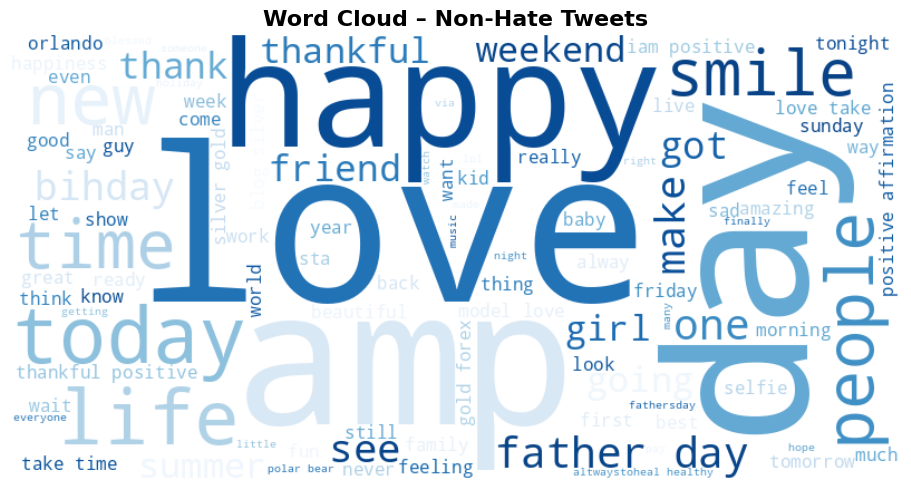

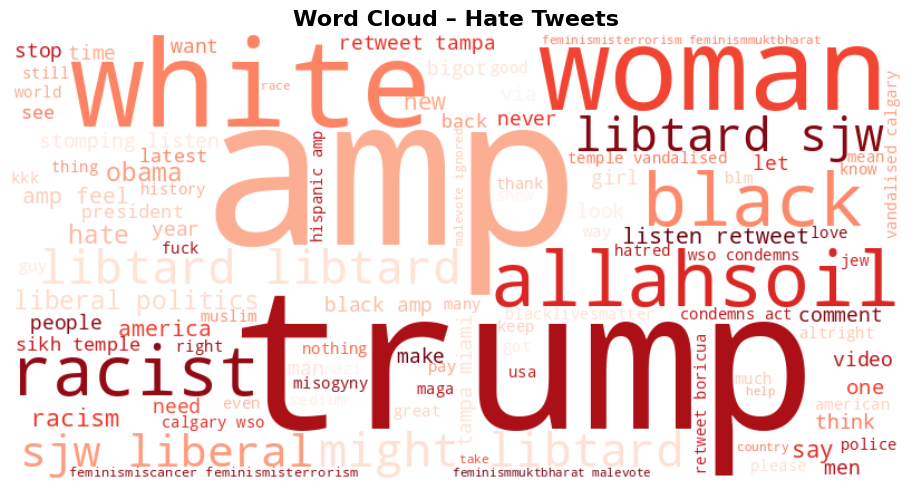

In [18]:
def generate_wordcloud(text_list, chart_title, colormap_name='Blues'):
    """
    Generate and display a word cloud from a list of text documents.

    Parameters
    text_list : array-like of str
        Collection of cleaned tweet strings to visualise.
    chart_title : str
        Title displayed above the word cloud figure.
    colormap_name : str, optional
        Matplotlib colormap to apply (default 'Blues').

    Returns
    None
        Renders the word cloud plot inline.
    """
    combined_corpus = ' '.join(text_list)
    wc = WordCloud(width=800, height=400, background_color='white',
                   colormap=colormap_name, max_words=100).generate(combined_corpus)
    plt.figure(figsize=(12, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(chart_title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Visualise the most frequent words in non-hate and hate tweets separately
generate_wordcloud(train_df[train_df['label'] == 0]['cleaned_tweet'].values,
                   'Word Cloud – Non-Hate Tweets', 'Blues')
generate_wordcloud(train_df[train_df['label'] == 1]['cleaned_tweet'].values,
                   'Word Cloud – Hate Tweets', 'Reds')


## 5. Tokenization & Sequence Padding

In [19]:
# VOCABULARY_SIZE: maximum number of unique tokens to keep in the vocabulary
# OOV_PLACEHOLDER: token inserted for words not seen during training
# EMBEDDING_DIM: dimensionality of trainable embedding vectors (Models 1 & 2)
# BATCH_SIZE: number of samples per gradient update step
# NUM_EPOCHS: maximum training epochs (early stopping may terminate earlier)
VOCABULARY_SIZE  = 10_000
OOV_PLACEHOLDER  = '<OOV>'
EMBEDDING_DIM    = 50
BATCH_SIZE       = 64
NUM_EPOCHS       = 20


In [20]:
# Separate feature texts and target labels from the training DataFrame
# Using the cleaned_tweet column produced in Section 4
tweet_texts  = train_df['cleaned_tweet'].values
tweet_labels = train_df['label'].values


In [21]:
# Split into 80 % training and 20 % validation subsets with stratification
# Stratification preserves the original class ratio in both subsets
X_train_texts, X_val_texts, y_train_labels, y_val_labels = train_test_split(
    tweet_texts, tweet_labels, test_size=0.2, random_state=42, stratify=tweet_labels
)
print(f"Training samples: {len(X_train_texts)} | Validation samples: {len(X_val_texts)}")


Training samples: 25569 | Validation samples: 6393


In [22]:
# Fit the Keras Tokenizer exclusively on training data to prevent data leakage
# Tokens beyond VOCABULARY_SIZE are replaced with the OOV_PLACEHOLDER at inference time
keras_tokenizer = Tokenizer(num_words=VOCABULARY_SIZE, oov_token=OOV_PLACEHOLDER)
keras_tokenizer.fit_on_texts(X_train_texts)
print(f"Full vocabulary size: {len(keras_tokenizer.word_index)} | Capped at: {VOCABULARY_SIZE}")


Full vocabulary size: 31856 | Capped at: 10000


In [23]:
# Use the 95th-percentile token length as the padding target
# This avoids inflating all sequences to match a handful of very long outliers
MAX_SEQUENCE_LEN = int(np.percentile(
    [len(seq.split()) for seq in X_train_texts], 95
))
print(f"MAX_SEQUENCE_LEN (95th percentile): {MAX_SEQUENCE_LEN}")


MAX_SEQUENCE_LEN (95th percentile): 12


In [24]:
# Convert text to integer sequences using the fitted tokenizer
train_sequences = keras_tokenizer.texts_to_sequences(X_train_texts)
val_sequences   = keras_tokenizer.texts_to_sequences(X_val_texts)
test_sequences  = keras_tokenizer.texts_to_sequences(test_df['cleaned_tweet'].values)

# Pad sequences to a uniform length; post-padding keeps the start of tokens intact
X_train_padded = pad_sequences(train_sequences, maxlen=MAX_SEQUENCE_LEN, padding='post', truncating='post')
X_val_padded   = pad_sequences(val_sequences,   maxlen=MAX_SEQUENCE_LEN, padding='post', truncating='post')
X_test_padded  = pad_sequences(test_sequences,  maxlen=MAX_SEQUENCE_LEN, padding='post', truncating='post')

print(f"X_train_padded shape: {X_train_padded.shape} | X_val_padded shape: {X_val_padded.shape}")


X_train_padded shape: (25569, 12) | X_val_padded shape: (6393, 12)


In [25]:
def plot_training_history(training_history, model_label):
    """
    Plot training vs. validation accuracy and loss curves side by side.

    Parameters
    training_history : keras.callbacks.History
        History object returned by model.fit().
    model_label : str
        Display name of the model used as the plot title prefix.

    Returns
    None
        Renders a 1×2 matplotlib figure inline.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, metric_name in zip(axes, ['accuracy', 'loss']):
        ax.plot(training_history.history[metric_name],
                label=f'Train {metric_name.capitalize()}')
        ax.plot(training_history.history[f'val_{metric_name}'],
                label=f'Validation {metric_name.capitalize()}')
        ax.set_title(f'{model_label} – {metric_name.capitalize()}')
        ax.set_xlabel('Epoch')
        ax.legend()
    plt.tight_layout()
    plt.show()


In [26]:
def evaluate_model(trained_model, padded_inputs, true_labels, model_label):
    """
    Evaluate a trained binary classification model and display results.

    Outputs validation accuracy, a full classification report (precision,
    recall, F1), and a colour-coded confusion matrix plot.

    Parameters
    trained_model : keras.Model
        The trained Keras model to evaluate.
    padded_inputs : np.ndarray
        Padded integer sequences for the evaluation split.
    true_labels : np.ndarray
        Ground-truth binary labels (0 or 1).
    model_label : str
        Display name shown in the printed output and plot titles.

    Returns
    tuple of (float, np.ndarray)
        Validation accuracy and the array of predicted labels.
    """
    predicted_probs  = trained_model.predict(padded_inputs, verbose=0)
    predicted_labels = (predicted_probs > 0.5).astype(int).flatten()
    val_accuracy = accuracy_score(true_labels, predicted_labels)
    print(f"\n{model_label} | Validation Accuracy: {val_accuracy*100:.2f}%")
    print(classification_report(true_labels, predicted_labels,
                                target_names=['Non-Hate', 'Hate']))
    ConfusionMatrixDisplay(
        confusion_matrix(true_labels, predicted_labels),
        display_labels=['Non-Hate', 'Hate']
    ).plot(cmap='Blues')
    plt.title(f'{model_label} – Confusion Matrix')
    plt.tight_layout()
    plt.show()
    return val_accuracy, predicted_labels


In [27]:
def build_callbacks(checkpoint_name):
    """
    Build a list of Keras training callbacks for early stopping and checkpointing.

    Early stopping monitors validation loss and halts training when no improvement
    is observed for 4 consecutive epochs, restoring the best weights automatically.
    ModelCheckpoint saves only the epoch that achieves the best validation accuracy.

    Parameters
    checkpoint_name : str
        Base name for the saved .h5 checkpoint file.

    Returns
    list
        [EarlyStopping, ModelCheckpoint] callback instances.
    """
    return [
        EarlyStopping(monitor='val_loss', patience=4,
                      restore_best_weights=True, verbose=1),
        ModelCheckpoint(f'{checkpoint_name}_best.h5',
                        monitor='val_accuracy', save_best_only=True, verbose=0)
    ]


## 6. Model 1 : Simple RNN with Trainable Embedding


### 6.1 Model Architecture


In [28]:
# Build Model 1: SimpleRNN with a trainable embedding layer
rnn_model = Sequential([
    Embedding(
        input_dim=VOCABULARY_SIZE,
        output_dim=EMBEDDING_DIM,
        input_shape=(MAX_SEQUENCE_LEN,)
    ),
    SimpleRNN(64),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
], name='Model1_SimpleRNN')

# Binary cross-entropy is appropriate for this binary classification task
rnn_model.compile(optimizer=Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])


### 6.2 Model Summary


In [29]:
rnn_model.summary()


Model: "Model1_SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 12, 50)         │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         7,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 509,473 (1.94 MB)

 Trainable params: 509,473 (1.94 MB)

 Non-trainable params: 0 (0.00 B)

### 6.3 Training & Evaluation


Epoch 1/20
396/400 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9233 - loss: 0.2611

400/400 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9450 - loss: 0.1867 - val_accuracy: 0.9596 - val_loss: 0.1313
Epoch 2/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9747 - loss: 0.0816 - val_accuracy: 0.9571 - val_loss: 0.1292
Epoch 3/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9888 - loss: 0.0392 - val_accuracy: 0.9570 - val_loss: 0.1729
Epoch 4/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9939 - loss: 0.0213 - val_accuracy: 0.9545 - val_loss: 0.2030
Epoch 5/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9956 - loss: 0.0157 - val_accuracy: 0.9445 - val_loss: 0.2314
Epoch 6/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9964 - loss: 0.0121 - val_accuracy: 0.9492 - val_loss: 0.2491
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 2.
Training time: 0.5 min


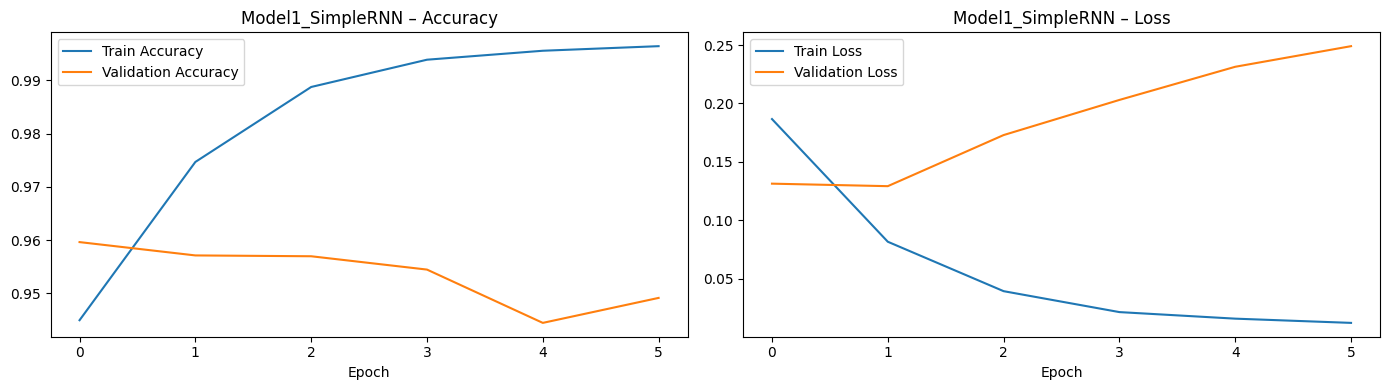


Model1_SimpleRNN | Validation Accuracy: 95.71%
              precision    recall  f1-score   support

    Non-Hate       0.97      0.98      0.98      5945
        Hate       0.73      0.61      0.67       448

    accuracy                           0.96      6393
   macro avg       0.85      0.80      0.82      6393
weighted avg       0.95      0.96      0.96      6393



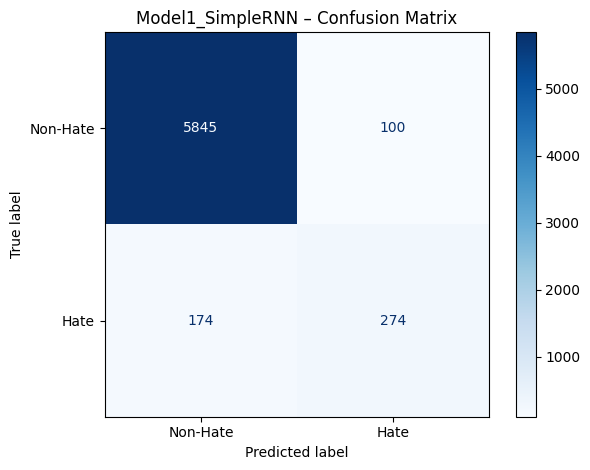

In [30]:
# Train Model 1 (SimpleRNN) with early stopping and model checkpointing
start_time = time.time()
rnn_history = rnn_model.fit(
    X_train_padded, y_train_labels,
    validation_data=(X_val_padded, y_val_labels),
    epochs=NUM_EPOCHS, batch_size=BATCH_SIZE,
    callbacks=build_callbacks('rnn_model'), verbose=1
)
print(f"Training time: {(time.time() - start_time) / 60:.1f} min")

# Plot learning curves and compute evaluation metrics for Model 1
plot_training_history(rnn_history, 'Model1_SimpleRNN')
rnn_accuracy, rnn_predictions = evaluate_model(
    rnn_model, X_val_padded, y_val_labels, 'Model1_SimpleRNN'
)


## 7. Model 2 : LSTM with Trainable Embedding


### 7.1 Model Architecture


In [31]:
# Build Model 2: LSTM with a trainable embedding layer
lstm_model = Sequential([
    Embedding(input_dim=VOCABULARY_SIZE, output_dim=EMBEDDING_DIM,
              input_length=MAX_SEQUENCE_LEN, input_shape=(MAX_SEQUENCE_LEN,)
),
    LSTM(64),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
], name='Model2_LSTM')

lstm_model.compile(optimizer=Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])


### 7.2 Model Summary


In [32]:
lstm_model.summary()


Model: "Model2_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 12, 50)         │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 531,553 (2.03 MB)

 Trainable params: 531,553 (2.03 MB)

 Non-trainable params: 0 (0.00 B)

### 7.3 Training


In [33]:
# Train Model 2 (LSTM with trainable embeddings) using the same callbacks
start_time = time.time()
lstm_history = lstm_model.fit(
    X_train_padded, y_train_labels,
    validation_data=(X_val_padded, y_val_labels),
    epochs=NUM_EPOCHS, batch_size=BATCH_SIZE,
    callbacks=build_callbacks('lstm_model'), verbose=1
)
print(f"Training time: {(time.time() - start_time) / 60:.1f} min")


Epoch 1/20
398/400 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9266 - loss: 0.2873

400/400 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.9456 - loss: 0.1950 - val_accuracy: 0.9604 - val_loss: 0.1200
Epoch 2/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9739 - loss: 0.0799

400/400 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9735 - loss: 0.0805 - val_accuracy: 0.9621 - val_loss: 0.1364
Epoch 3/20
399/400 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9854 - loss: 0.0495

400/400 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9832 - loss: 0.0552 - val_accuracy: 0.9623 - val_loss: 0.1430
Epoch 4/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9882 - loss: 0.0404 - val_accuracy: 0.9611 - val_loss: 0.1896
Epoch 5/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - accuracy: 0.9901 - loss: 0.0334 - val_accuracy: 0.9590 - val_loss: 0.1676
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.
Training time: 0.7 min


### 7.4 Evaluation


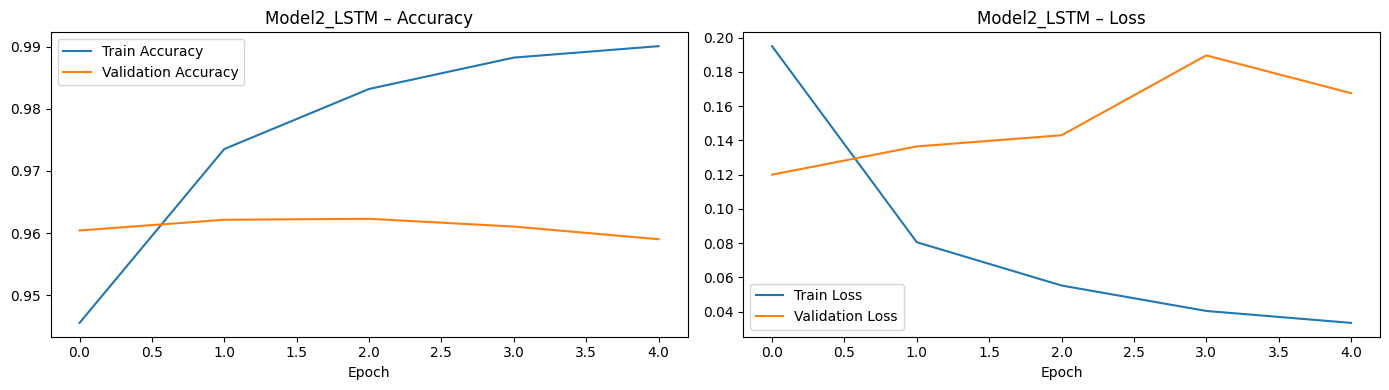


Model2_LSTM | Validation Accuracy: 96.04%
              precision    recall  f1-score   support

    Non-Hate       0.97      0.99      0.98      5945
        Hate       0.80      0.58      0.67       448

    accuracy                           0.96      6393
   macro avg       0.89      0.78      0.82      6393
weighted avg       0.96      0.96      0.96      6393



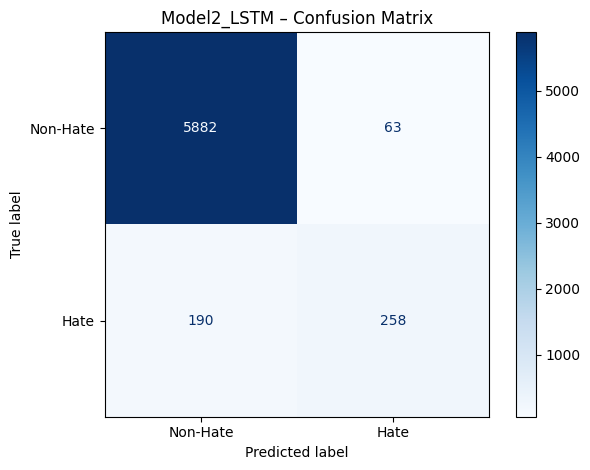

In [34]:
# Plot training curves and evaluate Model 2 on the validation set
plot_training_history(lstm_history, 'Model2_LSTM')
lstm_accuracy, lstm_predictions = evaluate_model(
    lstm_model, X_val_padded, y_val_labels, 'Model2_LSTM'
)


## 8. Model 3 : LSTM with Pre-trained Word2Vec Embeddings


### 8.1 Load Pre-trained Word2Vec Embeddings


In [35]:
# Download Google News Word2Vec vectors (~1.6 GB) via the Gensim API
# This step may take several minutes depending on network speed
w2v_embeddings    = gensim_api.load('word2vec-google-news-300')
W2V_EMBEDDING_DIM = 300   # must match the loaded model's vector dimensionality
print("Word2Vec pre-trained embeddings loaded successfully.")


[==================================================] 100.0% 1662.8/1662.8MB downloaded
Word2Vec pre-trained embeddings loaded successfully.


### 8.2 Embedding Weight Matrix


In [36]:
# Construct a weight matrix mapping each vocabulary index to its Word2Vec vector
# Words absent from the Word2Vec vocabulary are left as zero vectors
pretrained_weights = np.zeros((VOCABULARY_SIZE, W2V_EMBEDDING_DIM))
matched_word_count = 0

for vocab_word, word_index in keras_tokenizer.word_index.items():
    if word_index >= VOCABULARY_SIZE:
        continue
    if vocab_word in w2v_embeddings:
        pretrained_weights[word_index] = w2v_embeddings[vocab_word]
        matched_word_count += 1


In [37]:
# Report what fraction of the vocabulary is covered by Word2Vec
coverage_pct = matched_word_count / min(VOCABULARY_SIZE, len(keras_tokenizer.word_index)) * 100
print(f"Words mapped to Word2Vec: {matched_word_count} | Coverage: {coverage_pct:.1f}%")


Words mapped to Word2Vec: 7601 | Coverage: 76.0%


### 8.3 Model Architecture


In [38]:
# Build Model 3: LSTM with frozen pre-trained Word2Vec embedding
# Setting trainable=False preserves the pre-trained semantic structure during training
lstm_w2v_model = Sequential([
    Embedding(input_dim=VOCABULARY_SIZE, output_dim=W2V_EMBEDDING_DIM,
              weights=[pretrained_weights],input_shape=(MAX_SEQUENCE_LEN,)
,
              trainable=False),
    LSTM(64),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
], name='Model3_LSTM_Word2Vec')

lstm_w2v_model.compile(optimizer=Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
lstm_w2v_model.summary()


Model: "Model3_LSTM_Word2Vec"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 12, 300)        │     3,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        93,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,095,553 (11.81 MB)

 Trainable params: 95,553 (373.25 KB)

 Non-trainable params: 3,000,000 (11.44 MB)

In [39]:
# Summary already printed above


### 8.4 Model Training


In [40]:
# Train Model 3 (LSTM + Word2Vec) using the same callback strategy
start_time = time.time()
lstm_w2v_history = lstm_w2v_model.fit(
    X_train_padded, y_train_labels,
    validation_data=(X_val_padded, y_val_labels),
    epochs=NUM_EPOCHS, batch_size=BATCH_SIZE,
    callbacks=build_callbacks('lstm_w2v_model'), verbose=1
)
print(f"Training time: {(time.time() - start_time) / 60:.1f} min")


Epoch 1/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9224 - loss: 0.2668

400/400 ━━━━━━━━━━━━━━━━━━━━ 23s 47ms/step - accuracy: 0.9380 - loss: 0.1911 - val_accuracy: 0.9476 - val_loss: 0.1491
Epoch 2/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9498 - loss: 0.1462

400/400 ━━━━━━━━━━━━━━━━━━━━ 19s 43ms/step - accuracy: 0.9507 - loss: 0.1434 - val_accuracy: 0.9490 - val_loss: 0.1438
Epoch 3/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9553 - loss: 0.1320

400/400 ━━━━━━━━━━━━━━━━━━━━ 17s 42ms/step - accuracy: 0.9547 - loss: 0.1319 - val_accuracy: 0.9515 - val_loss: 0.1401
Epoch 4/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9596 - loss: 0.1164

400/400 ━━━━━━━━━━━━━━━━━━━━ 17s 42ms/step - accuracy: 0.9567 - loss: 0.1233 - val_accuracy: 0.9548 - val_loss: 0.1393
Epoch 5/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9608 - loss: 0.1119

400/400 ━━━━━━━━━━━━━━━━━━━━ 16s 40ms/step - accuracy: 0.9603 - loss: 0.1148 - val_accuracy: 0.9556 - val_loss: 0.1322
Epoch 6/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 17s 44ms/step - accuracy: 0.9637 - loss: 0.1046 - val_accuracy: 0.9556 - val_loss: 0.1275
Epoch 7/20
397/400 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9666 - loss: 0.0941

400/400 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - accuracy: 0.9672 - loss: 0.0966 - val_accuracy: 0.9562 - val_loss: 0.1378
Epoch 8/20
399/400 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9720 - loss: 0.0868

400/400 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.9702 - loss: 0.0879 - val_accuracy: 0.9582 - val_loss: 0.1429
Epoch 9/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9740 - loss: 0.0770 - val_accuracy: 0.9485 - val_loss: 0.1458
Epoch 10/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9760 - loss: 0.0715

400/400 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.9765 - loss: 0.0698 - val_accuracy: 0.9601 - val_loss: 0.1376
Epoch 10: early stopping
Restoring model weights from the end of the best epoch: 6.
Training time: 2.5 min


### 8.5 Model Evaluation


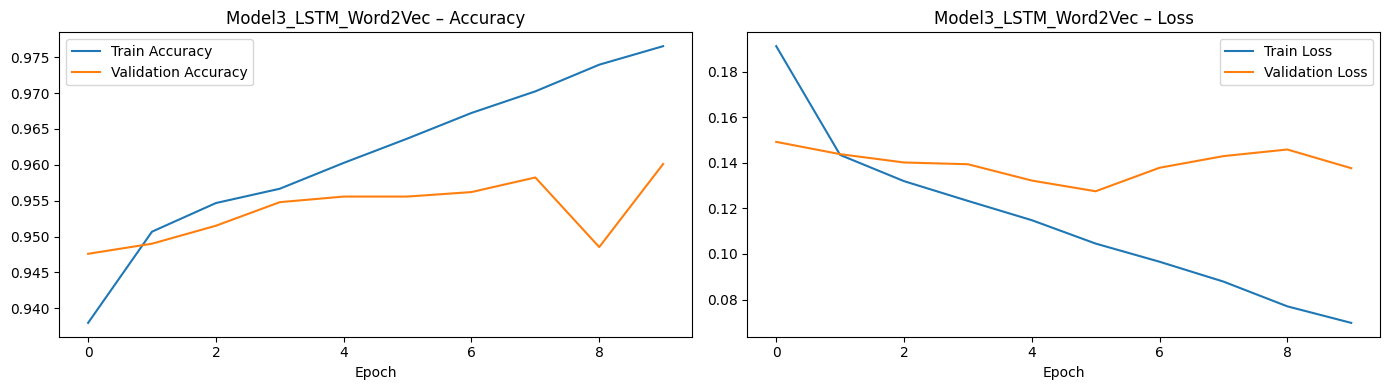


Model3_LSTM_Word2Vec | Validation Accuracy: 95.56%
              precision    recall  f1-score   support

    Non-Hate       0.96      0.99      0.98      5945
        Hate       0.77      0.52      0.62       448

    accuracy                           0.96      6393
   macro avg       0.87      0.75      0.80      6393
weighted avg       0.95      0.96      0.95      6393



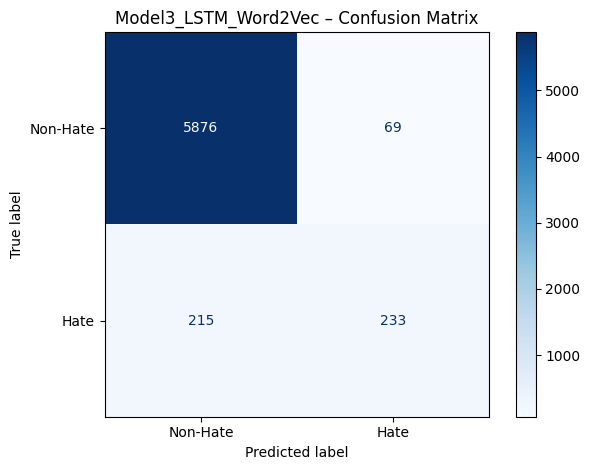

In [41]:
# Plot training curves and evaluate Model 3 on the validation set
plot_training_history(lstm_w2v_history, 'Model3_LSTM_Word2Vec')
lstm_w2v_accuracy, lstm_w2v_predictions = evaluate_model(
    lstm_w2v_model, X_val_padded, y_val_labels, 'Model3_LSTM_Word2Vec'
)


## 9. Comparative Analysis : Model 1 vs. Model 2 vs. Model 3


### 9.1 Validation Accuracy Comparison


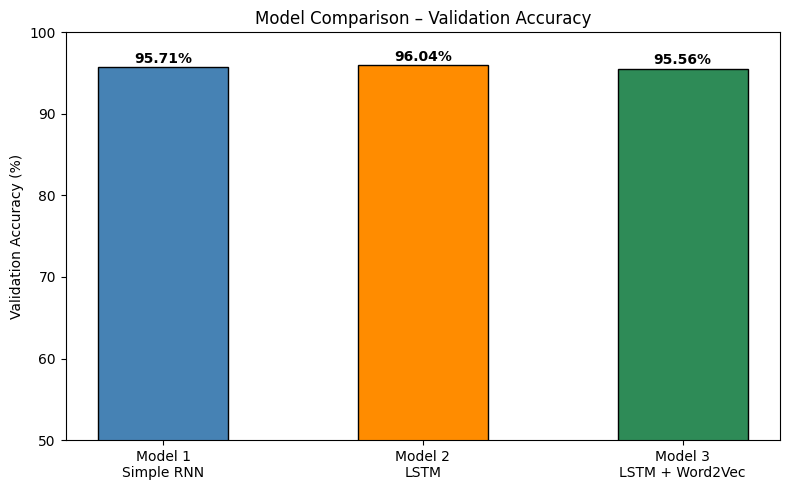

In [42]:
# Bar chart comparing final validation accuracy for all three models
comparison_labels     = ['Model 1\nSimple RNN', 'Model 2\nLSTM', 'Model 3\nLSTM + Word2Vec']
comparison_accuracies = [rnn_accuracy * 100, lstm_accuracy * 100, lstm_w2v_accuracy * 100]

plt.figure(figsize=(8, 5))
accuracy_bars = plt.bar(comparison_labels, comparison_accuracies,
                        color=['steelblue', 'darkorange', 'seagreen'],
                        edgecolor='black', width=0.5)
plt.ylim(50, 100)
plt.ylabel('Validation Accuracy (%)')
plt.title('Model Comparison – Validation Accuracy')
for bar_item, acc_val in zip(accuracy_bars, comparison_accuracies):
    plt.text(bar_item.get_x() + bar_item.get_width() / 2,
             bar_item.get_height() + 0.5,
             f'{acc_val:.2f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


### 9.2 Validation Loss Comparison Across Epochs


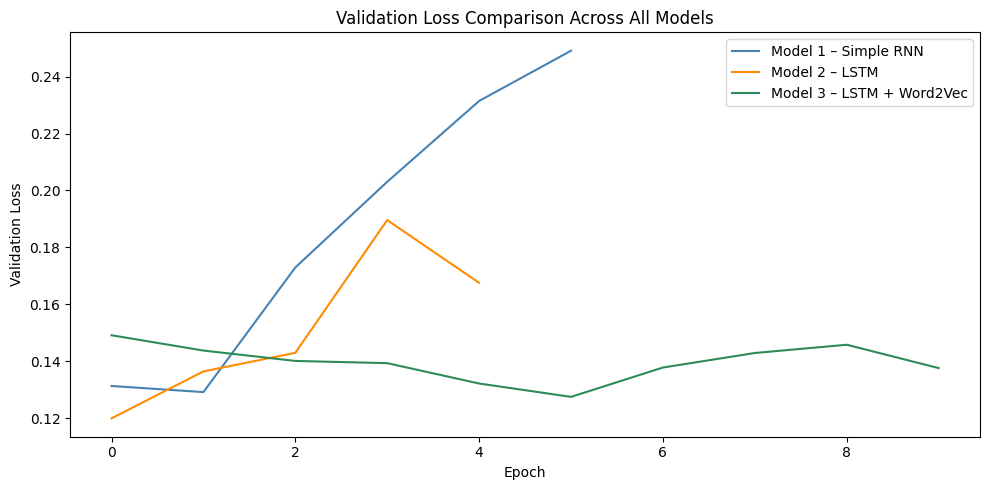

In [43]:
# Overlay validation loss curves to compare convergence behaviour across all three models
plt.figure(figsize=(10, 5))
plt.plot(rnn_history.history['val_loss'],      label='Model 1 – Simple RNN',    color='steelblue')
plt.plot(lstm_history.history['val_loss'],     label='Model 2 – LSTM',           color='darkorange')
plt.plot(lstm_w2v_history.history['val_loss'], label='Model 3 – LSTM + Word2Vec',color='seagreen')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Validation Loss Comparison Across All Models')
plt.legend()
plt.tight_layout()
plt.show()


### 9.3 Model Performance Summary Table


In [44]:
# Tabular summary of model configurations and final validation accuracy
results_summary = pd.DataFrame({
    'Model'         : ['Model1_SimpleRNN', 'Model2_LSTM', 'Model3_LSTM_Word2Vec'],
    'Embedding Type': ['Trainable', 'Trainable', 'Pre-trained Word2Vec (frozen)'],
    'Val Accuracy'  : [
        f'{rnn_accuracy*100:.2f}%',
        f'{lstm_accuracy*100:.2f}%',
        f'{lstm_w2v_accuracy*100:.2f}%'
    ],
})
print(results_summary.to_string(index=False))


               Model                Embedding Type Val Accuracy
    Model1_SimpleRNN                     Trainable       95.71%
         Model2_LSTM                     Trainable       96.04%
Model3_LSTM_Word2Vec Pre-trained Word2Vec (frozen)       95.56%


## 10. Error Analysis


### 10.1 Identify Misclassified Samples


In [45]:
# Reconstruct the validation-set indices to align Model 3 predictions with original tweets
_, val_indices = train_test_split(
    np.arange(len(train_df)), test_size=0.2,
    random_state=42, stratify=train_df['label'].values
)

# Build an analysis DataFrame with true vs. predicted labels for Model 3
val_analysis_df = train_df.iloc[val_indices].copy().reset_index(drop=True)
val_analysis_df['predicted_label'] = lstm_w2v_predictions
val_analysis_df['is_correct']      = (val_analysis_df['label'] == val_analysis_df['predicted_label'])

misclassified_df = val_analysis_df[~val_analysis_df['is_correct']].reset_index(drop=True)
print(f"Misclassified: {len(misclassified_df)} / {len(val_analysis_df)} "
      f"({len(misclassified_df)/len(val_analysis_df)*100:.1f}%)")


Misclassified: 284 / 6393 (4.4%)


### 10.2 Inspect Incorrect Predictions


In [46]:
# Display 2–3 incorrect predictions with the original tweet and both true/predicted labels
for error_idx in range(min(3, len(misclassified_df))):
    error_row = misclassified_df.iloc[error_idx]
    true_name = 'Hate' if error_row['label'] == 1 else 'Non-Hate'
    pred_name = 'Hate' if error_row['predicted_label'] == 1 else 'Non-Hate'
    print(f"\nExample {error_idx + 1}")
    print(f"  Tweet          : {error_row['tweet']}")
    print(f"  True Label     : {int(error_row['label'])} ({true_name})")
    print(f"  Predicted Label: {int(error_row['predicted_label'])} ({pred_name})")



Example 1
  Tweet          : beware the "snowball effect" blackman! pa 2   
  True Label     : 1 (Hate)
  Predicted Label: 0 (Non-Hate)

Example 2
  Tweet          : the immature @user is just trying to make a fool of @user   #xenophobe #immature #moron 
  True Label     : 1 (Hate)
  Predicted Label: 0 (Non-Hate)

Example 3
  Tweet          :  porn vids web free sex 
  True Label     : 1 (Hate)
  Predicted Label: 0 (Non-Hate)


### 10.3 False Positive / False Negative Breakdown


In [47]:
# Count and report false positives and false negatives to understand error direction
false_positive_count = len(
    val_analysis_df[(val_analysis_df['label'] == 0) & (val_analysis_df['predicted_label'] == 1)]
)
false_negative_count = len(
    val_analysis_df[(val_analysis_df['label'] == 1) & (val_analysis_df['predicted_label'] == 0)]
)
print(f"False Positives (predicted Hate, actually Non-Hate): {false_positive_count}")
print(f"False Negatives (predicted Non-Hate, actually Hate): {false_negative_count}")


False Positives (predicted Hate, actually Non-Hate): 69
False Negatives (predicted Non-Hate, actually Hate): 215


### 10.4 Possible Reasons for Misclassification
- The model struggles to correctly interpret **sarcasm and ironic expressions**, which often invert the intended meaning.
- **Very short tweets** provide limited contextual information, making accurate classification more difficult.
- The presence of **domain-specific slang or informal language** that is not included in the pretrained Word2Vec vocabulary reduces model understanding.
- A significant **class imbalance (approximately 93% normal tweets)** biases the model toward predicting the majority class.


### 10.5 Suggested Improvements
- Apply **class weighting techniques** to penalize misclassification of minority classes, especially hate speech.
- Explore more advanced architectures such as **Bidirectional LSTM layers** to capture context from both directions.
- Utilize **Twitter-specific pretrained embeddings** (e.g., GloVe Twitter embeddings) for better representation of informal text.
- Perform **domain-specific fine-tuning of embeddings** using datasets related to hate speech to improve contextual understanding.